# Cross-Config Monotonicity Checks

Theoretically guaranteed conditions on MSE that *must* hold if optimization succeeded:

1. **More depth → lower MSE**: A deeper network can represent shallower solutions
2. **Greater m → lower MSE**: More bottleneck capacity can only help
3. **Smaller n → lower MSE**: Fewer features is an easier task
4. **Greater S → lower MSE**: Higher sparsity means fewer active features

Any violation is **definitively** an optimization failure — not ambiguous, not a phase transition effect.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import json
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

df = pd.read_csv('results_db/compiled/sweep_results.csv')
df['n_over_m'] = df['n'] / df['m']

n_vals = sorted(df.n.unique())
m_vals = sorted(df.m.unique())
l_vals = sorted(df.l.unique())
S_vals = sorted(df.S.unique())

# Also load per-seed data for deeper inspection
def load_seeds(n, m, l, S):
    path = Path(f'results_db/seeds/n{n}_m{m}_l{l}_S{S}.json')
    if path.exists():
        with open(path) as f:
            return json.load(f)['seeds']
    return []

print(f'{len(df)} configs loaded')
print(f'MSE range: [{df.mse_full.min():.5f}, {df.mse_full.max():.5f}]')

216 configs loaded
MSE range: [0.00022, 0.04313]


In [2]:
# Find all monotonicity violations
violations = []
df_idx = df.set_index(['n', 'm', 'l', 'S'])

for _, row in df.iterrows():
    n, m, l, S = int(row['n']), int(row['m']), int(row['l']), row['S']
    mse = row['mse_full']
    
    # 1. More depth → <= MSE
    for l2 in range(l + 1, 5):
        key = (n, m, l2, S)
        if key in df_idx.index:
            mse2 = df_idx.loc[key, 'mse_full']
            if mse2 > mse * 1.001:  # 0.1% tolerance
                violations.append({
                    'type': 'depth', 'n': n, 'm': m, 'S': S,
                    'param_better': l, 'param_worse': l2,
                    'mse_better': mse, 'mse_worse': float(mse2),
                    'severity': float(mse2 - mse),
                    'rel_severity': float((mse2 - mse) / mse),
                })
    
    # 2. Greater m → <= MSE
    mi = m_vals.index(m) if m in m_vals else -1
    for mi2 in range(mi + 1, len(m_vals)):
        m2 = m_vals[mi2]
        if m2 >= n:
            continue
        key = (n, m2, l, S)
        if key in df_idx.index:
            mse2 = df_idx.loc[key, 'mse_full']
            if mse2 > mse * 1.001:
                violations.append({
                    'type': 'bottleneck', 'n': n, 'l': l, 'S': S,
                    'param_better': m, 'param_worse': m2,
                    'mse_better': mse, 'mse_worse': float(mse2),
                    'severity': float(mse2 - mse),
                    'rel_severity': float((mse2 - mse) / mse),
                })
    
    # 3. Smaller n → <= MSE
    ni = n_vals.index(n) if n in n_vals else -1
    for ni2 in range(0, ni):
        n2 = n_vals[ni2]
        if m >= n2:
            continue
        key = (n2, m, l, S)
        if key in df_idx.index:
            mse2 = df_idx.loc[key, 'mse_full']
            if mse2 > mse * 1.001:
                violations.append({
                    'type': 'input_dim', 'm': m, 'l': l, 'S': S,
                    'param_better': n, 'param_worse': n2,
                    'mse_better': mse, 'mse_worse': float(mse2),
                    'severity': float(mse2 - mse),
                    'rel_severity': float((mse2 - mse) / mse),
                })
    
    # 4. Greater S → <= MSE
    si = S_vals.index(S) if S in S_vals else -1
    for si2 in range(si + 1, len(S_vals)):
        S2 = S_vals[si2]
        key = (n, m, l, S2)
        if key in df_idx.index:
            mse2 = df_idx.loc[key, 'mse_full']
            if mse2 > mse * 1.001:
                violations.append({
                    'type': 'sparsity', 'n': n, 'm': m, 'l': l,
                    'param_better': S, 'param_worse': S2,
                    'mse_better': mse, 'mse_worse': float(mse2),
                    'severity': float(mse2 - mse),
                    'rel_severity': float((mse2 - mse) / mse),
                })

vdf = pd.DataFrame(violations)

print(f'Total violations: {len(vdf)} / ~{len(df) * 4} comparisons')
print()
for vtype in ['depth', 'bottleneck', 'input_dim', 'sparsity']:
    sub = vdf[vdf.type == vtype]
    if len(sub) > 0:
        print(f'{vtype:12s}: {len(sub):3d} violations, '
              f'median severity={sub.severity.median():.5f}, '
              f'max={sub.severity.max():.5f}, '
              f'median relative={sub.rel_severity.median():.1%}')
    else:
        print(f'{vtype:12s}:   0 violations')

Total violations: 240 / ~864 comparisons

depth       : 124 violations, median severity=0.00581, max=0.03591, median relative=127.2%
bottleneck  :  98 violations, median severity=0.00444, max=0.01516, median relative=32.1%
input_dim   :   8 violations, median severity=0.00191, max=0.00506, median relative=63.9%
sparsity    :  10 violations, median severity=0.00257, max=0.00689, median relative=69.7%


## Depth Violations
The dominant failure: deeper networks getting worse MSE than shallower ones.

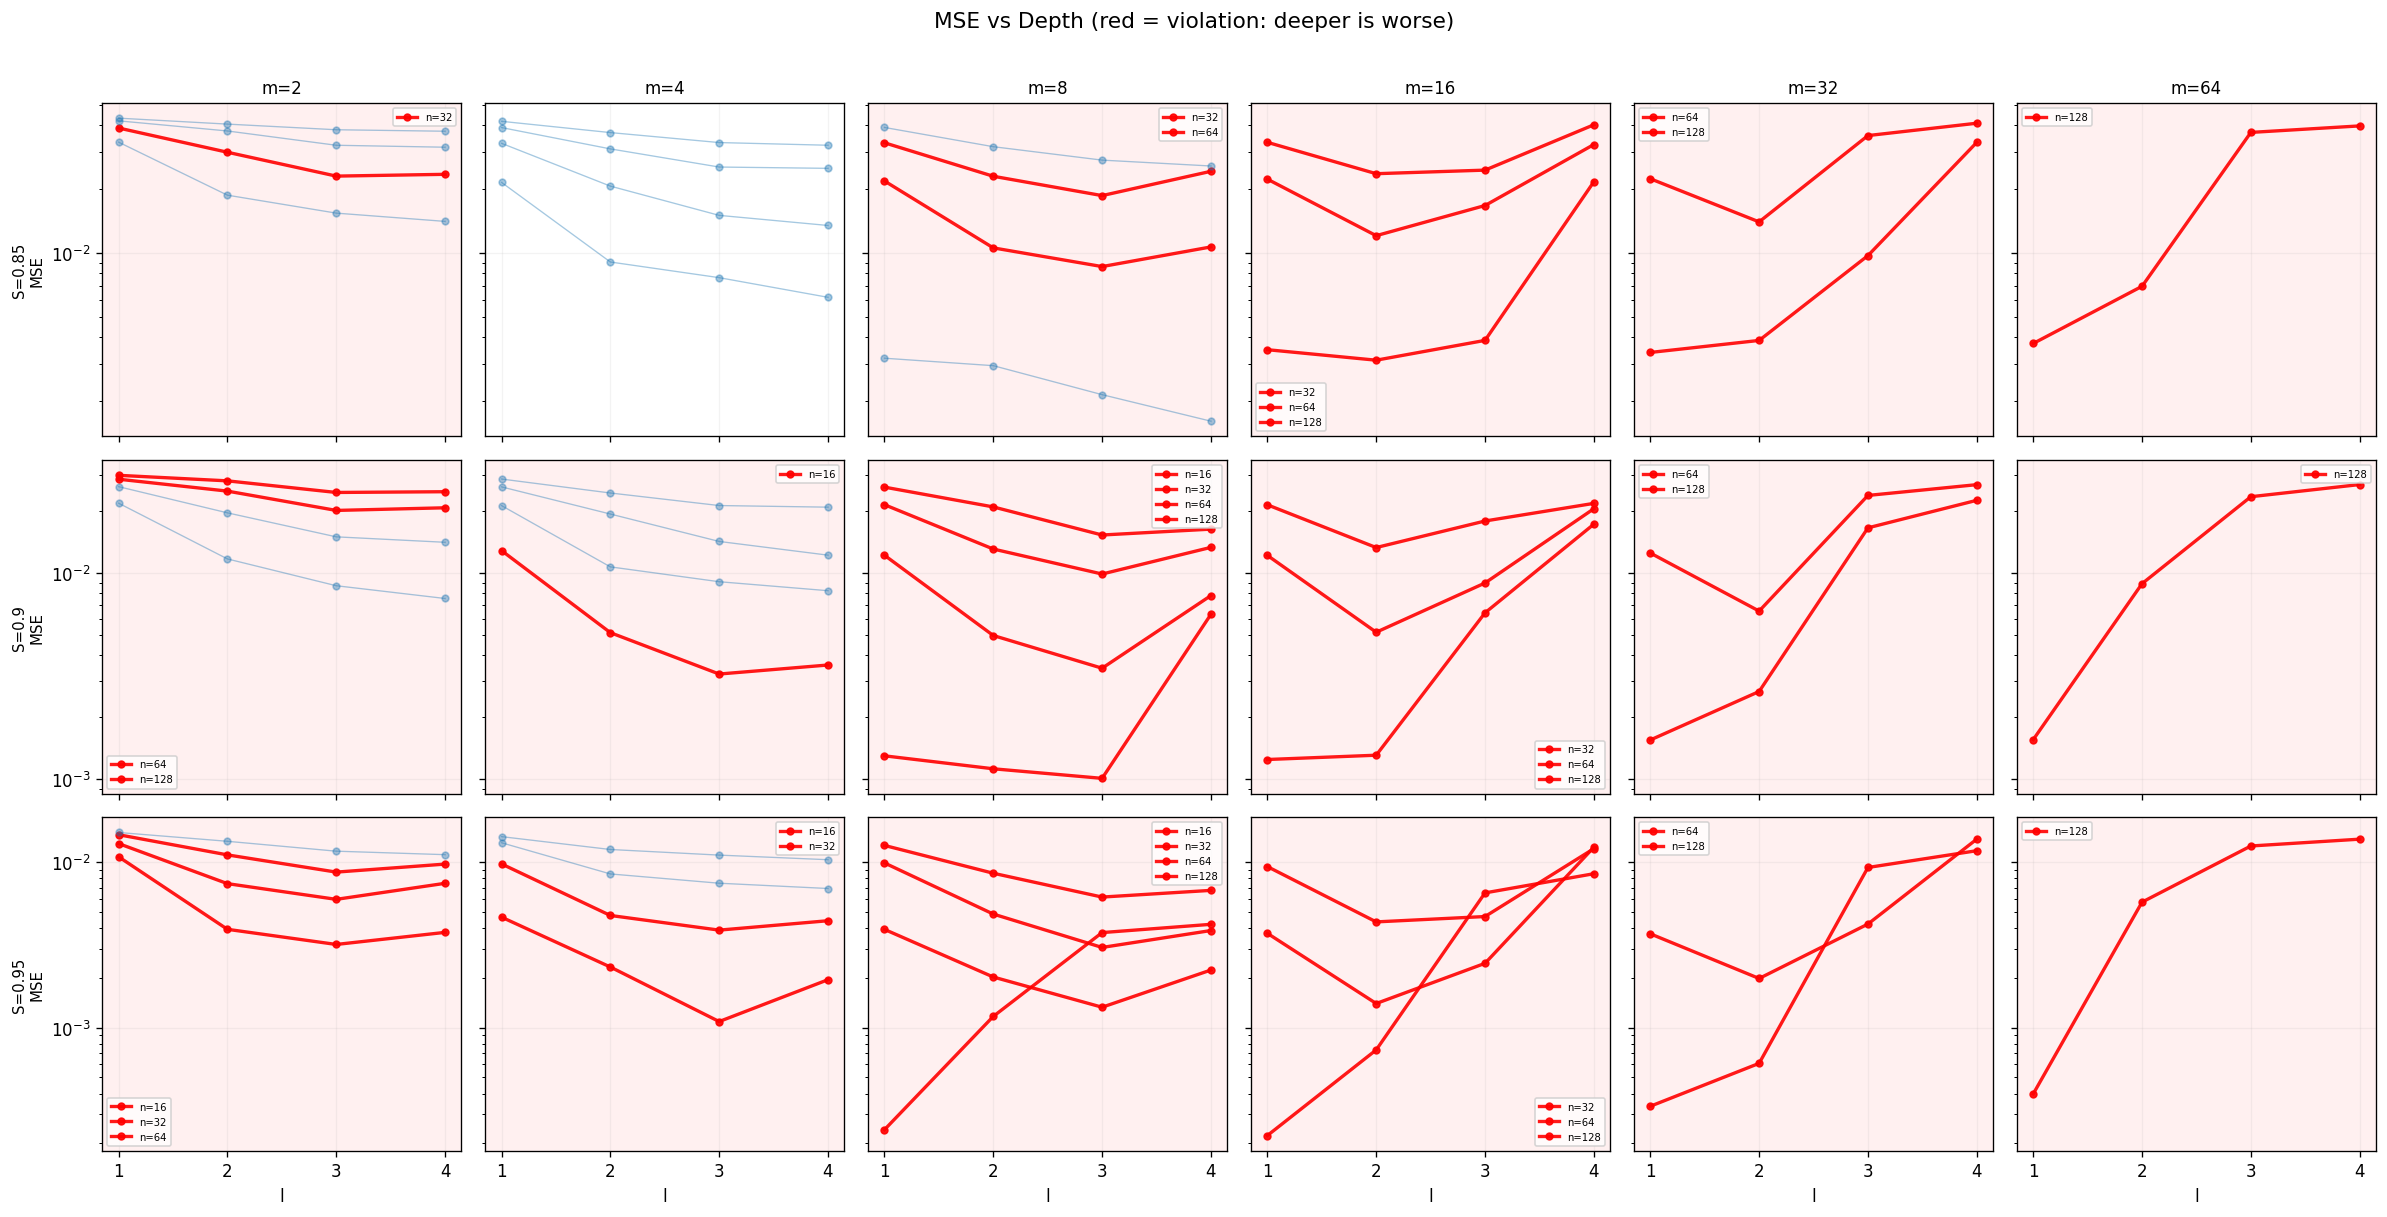

Depth violation breakdown:
  l=1→l=2: 9 violations, median relative=85.9%
  l=1→l=3: 13 violations, median relative=886.9%
  l=1→l=4: 20 violations, median relative=452.0%
  l=2→l=3: 19 violations, median relative=150.9%
  l=2→l=4: 26 violations, median relative=231.4%
  l=3→l=4: 37 violations, median relative=26.3%


In [3]:
# Depth: MSE vs l for each (n, m, S)
fig, axes = plt.subplots(len(S_vals), len(m_vals), figsize=(20, 10),
                          sharex=True, sharey='row')

depth_v = vdf[vdf.type == 'depth']

for si, S in enumerate(S_vals):
    for mi, m in enumerate(m_vals):
        ax = axes[si, mi]
        has_violation = False
        
        for n in n_vals:
            if m >= n:
                continue
            sub = df[(df.n == n) & (df.m == m) & (df.S == S)].sort_values('l')
            if len(sub) < 2:
                continue
            
            mses = sub['mse_full'].values
            ls = sub['l'].values
            
            # Check if this line has any non-monotonicity
            is_bad = any(mses[i+1] > mses[i] * 1.001 for i in range(len(mses)-1))
            color = 'red' if is_bad else 'C0'
            lw = 2 if is_bad else 0.8
            alpha = 0.9 if is_bad else 0.4
            
            ax.plot(ls, mses, 'o-', color=color, lw=lw, alpha=alpha, ms=4,
                   label=f'n={n}' if is_bad else '')
            if is_bad:
                has_violation = True
        
        ax.set_yscale('log')
        if si == 0:
            ax.set_title(f'm={m}', fontsize=10)
        if mi == 0:
            ax.set_ylabel(f'S={S}\nMSE', fontsize=9)
        if si == len(S_vals) - 1:
            ax.set_xlabel('l')
        ax.set_xticks([1, 2, 3, 4])
        if has_violation:
            ax.patch.set_facecolor('#fff0f0')
            ax.legend(fontsize=6)
        ax.grid(alpha=0.15)

fig.suptitle('MSE vs Depth (red = violation: deeper is worse)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Which depth transitions are most violated?
print('Depth violation breakdown:')
for l1 in [1, 2, 3]:
    for l2 in range(l1 + 1, 5):
        sub = depth_v[(depth_v.param_better == l1) & (depth_v.param_worse == l2)]
        if len(sub) > 0:
            print(f'  l={l1}→l={l2}: {len(sub)} violations, '
                  f'median relative={sub.rel_severity.median():.1%}')

/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_97065/3795493961.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


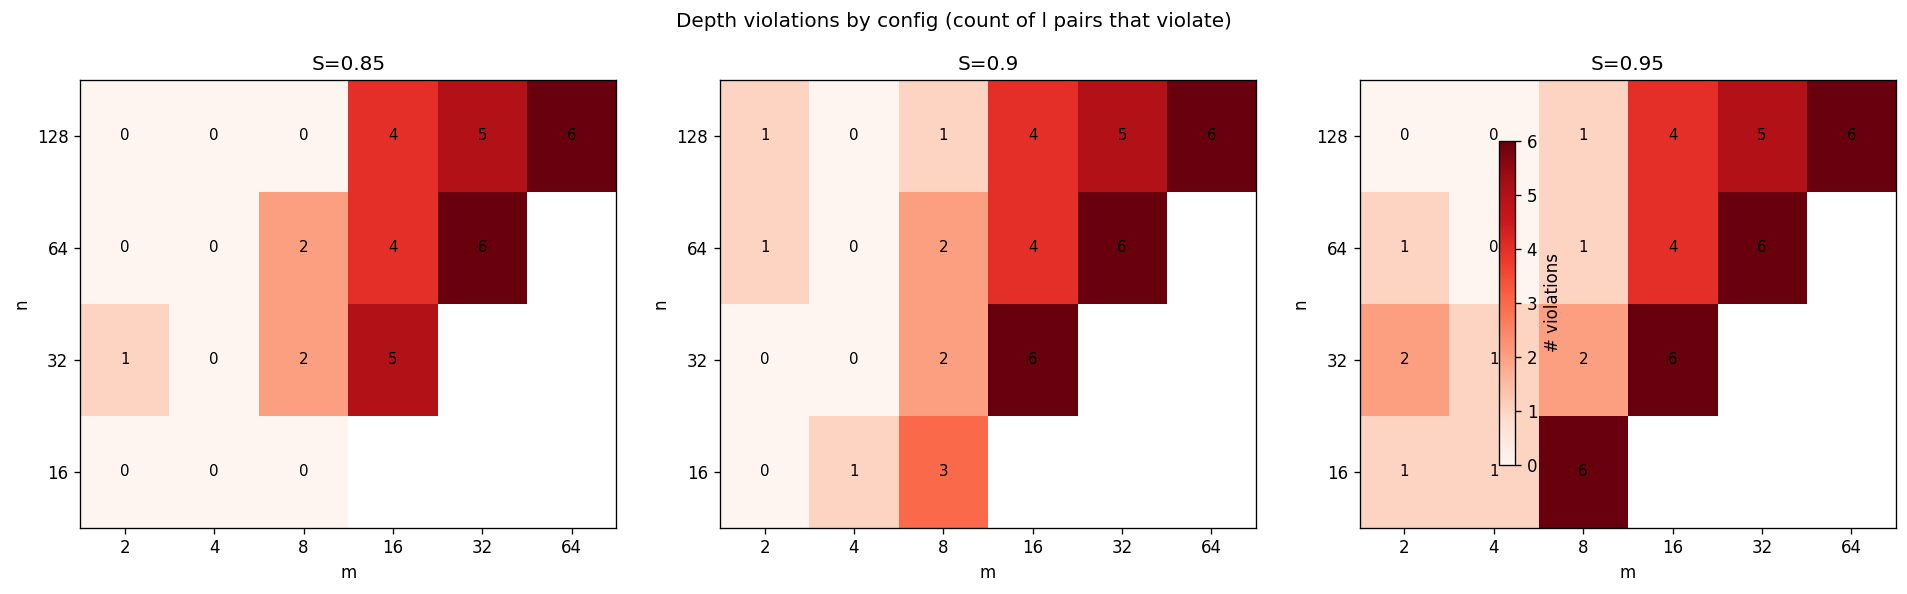

In [4]:
# Where in config space do depth violations cluster?
depth_v = vdf[vdf.type == 'depth'].copy()

# Count violations per (n, m, S) group
if len(depth_v) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for si, S in enumerate(S_vals):
        ax = axes[si]
        ax.set_title(f'S={S}')
        
        # For each (n, m), count how many depth violations exist
        grid = np.zeros((len(n_vals), len(m_vals)))
        for _, v in depth_v[depth_v.S == S].iterrows():
            ni = n_vals.index(v['n'])
            mi = m_vals.index(v['m'])
            grid[ni, mi] += 1
        
        # Mark invalid cells
        for ni, n in enumerate(n_vals):
            for mi, m in enumerate(m_vals):
                if m >= n:
                    grid[ni, mi] = np.nan
        
        im = ax.imshow(grid, cmap='Reds', vmin=0, vmax=6,
                       aspect='auto', origin='lower')
        for ni, n in enumerate(n_vals):
            for mi, m in enumerate(m_vals):
                if not np.isnan(grid[ni, mi]):
                    ax.text(mi, ni, f'{int(grid[ni, mi])}', 
                           ha='center', va='center', fontsize=9)
        
        ax.set_xticks(range(len(m_vals)))
        ax.set_xticklabels(m_vals)
        ax.set_yticks(range(len(n_vals)))
        ax.set_yticklabels(n_vals)
        ax.set_xlabel('m')
        ax.set_ylabel('n')
    
    fig.suptitle('Depth violations by config (count of l pairs that violate)', fontsize=12)
    fig.colorbar(im, ax=axes, label='# violations', shrink=0.7)
    plt.tight_layout()
    plt.show()

## Bottleneck Violations
Wider bottleneck getting worse MSE — definitively wrong.

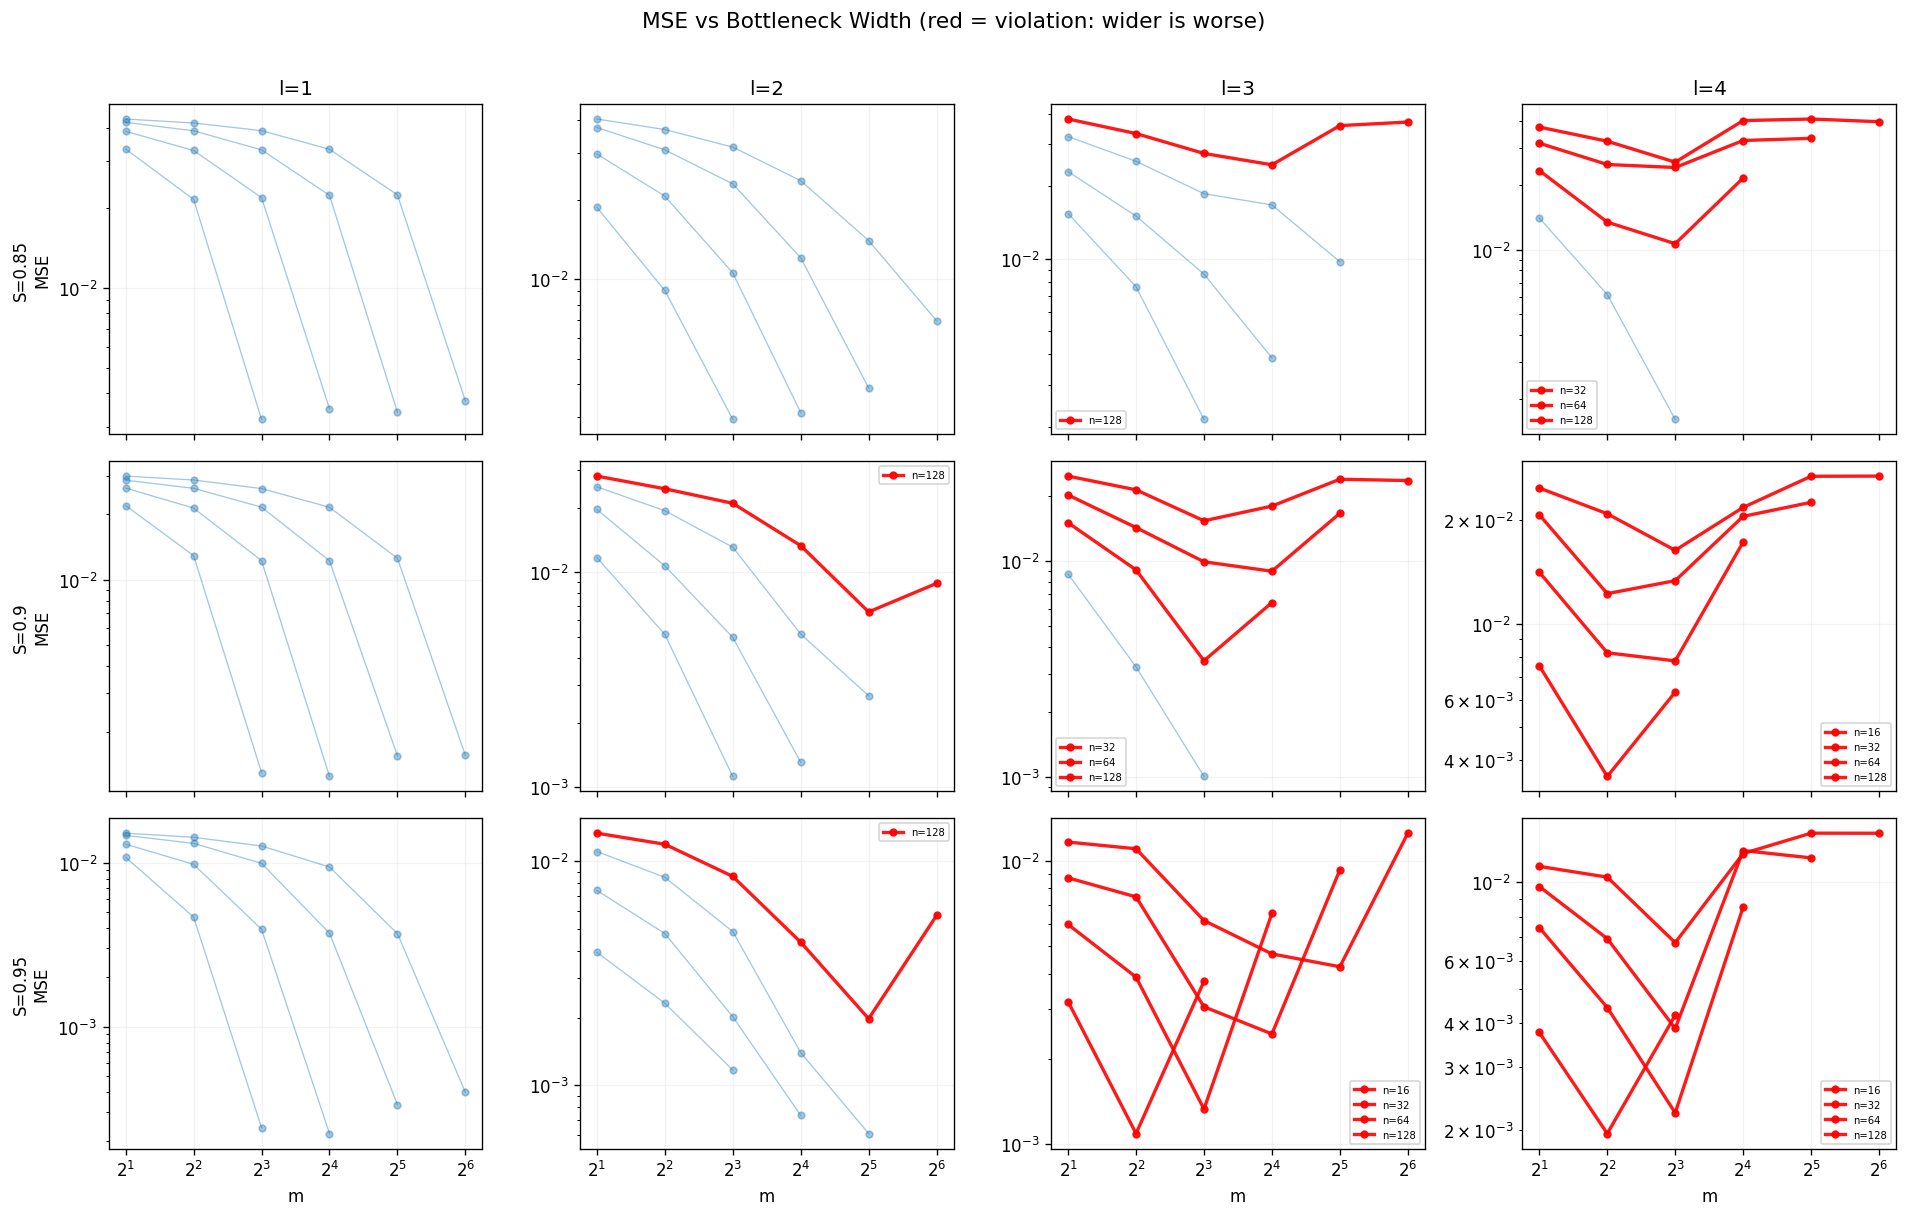

Bottleneck violations: 98
      type     n   m    S  param_better  param_worse  mse_better  mse_worse  severity  rel_severity   l
bottleneck 128.0 NaN 0.85           8.0         32.0    0.025670   0.040825  0.015155      0.590382 4.0
bottleneck 128.0 NaN 0.85           8.0         16.0    0.025670   0.040134  0.014464      0.563449 4.0
bottleneck 128.0 NaN 0.85           8.0         64.0    0.025670   0.039656  0.013986      0.544826 4.0
bottleneck 128.0 NaN 0.85          16.0         64.0    0.024546   0.036954  0.012409      0.505538 3.0
bottleneck 128.0 NaN 0.85          16.0         32.0    0.024546   0.035707  0.011161      0.454699 3.0
bottleneck  32.0 NaN 0.85           8.0         16.0    0.010670   0.021627  0.010956      1.026798 4.0
bottleneck 128.0 NaN 0.90           8.0         64.0    0.016363   0.026932  0.010569      0.645891 4.0
bottleneck 128.0 NaN 0.90           8.0         32.0    0.016363   0.026898  0.010535      0.643836 4.0
bottleneck  64.0 NaN 0.90           4.

In [5]:
# MSE vs m for each (n, l, S)
fig, axes = plt.subplots(len(S_vals), len(l_vals), figsize=(16, 10),
                          sharex=True)

for si, S in enumerate(S_vals):
    for li, l in enumerate(l_vals):
        ax = axes[si, li]
        
        for n in n_vals:
            sub = df[(df.n == n) & (df.l == l) & (df.S == S)].sort_values('m')
            if len(sub) < 2:
                continue
            
            mses = sub['mse_full'].values
            ms = sub['m'].values
            is_bad = any(mses[i+1] > mses[i] * 1.001 for i in range(len(mses)-1))
            
            color = 'red' if is_bad else 'C0'
            lw = 2 if is_bad else 0.8
            alpha = 0.9 if is_bad else 0.4
            ax.plot(ms, mses, 'o-', color=color, lw=lw, alpha=alpha, ms=4,
                   label=f'n={n}' if is_bad else '')
        
        ax.set_xscale('log', base=2)
        ax.set_yscale('log')
        if si == 0:
            ax.set_title(f'l={l}')
        if li == 0:
            ax.set_ylabel(f'S={S}\nMSE')
        if si == len(S_vals) - 1:
            ax.set_xlabel('m')
        if ax.get_legend_handles_labels()[1]:
            ax.legend(fontsize=6)
        ax.grid(alpha=0.15)

fig.suptitle('MSE vs Bottleneck Width (red = violation: wider is worse)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

bneck_v = vdf[vdf.type == 'bottleneck']
if len(bneck_v) > 0:
    print(f'Bottleneck violations: {len(bneck_v)}')
    print(bneck_v.sort_values('severity', ascending=False).head(10).to_string(index=False))

## All Violations: Severity Distribution

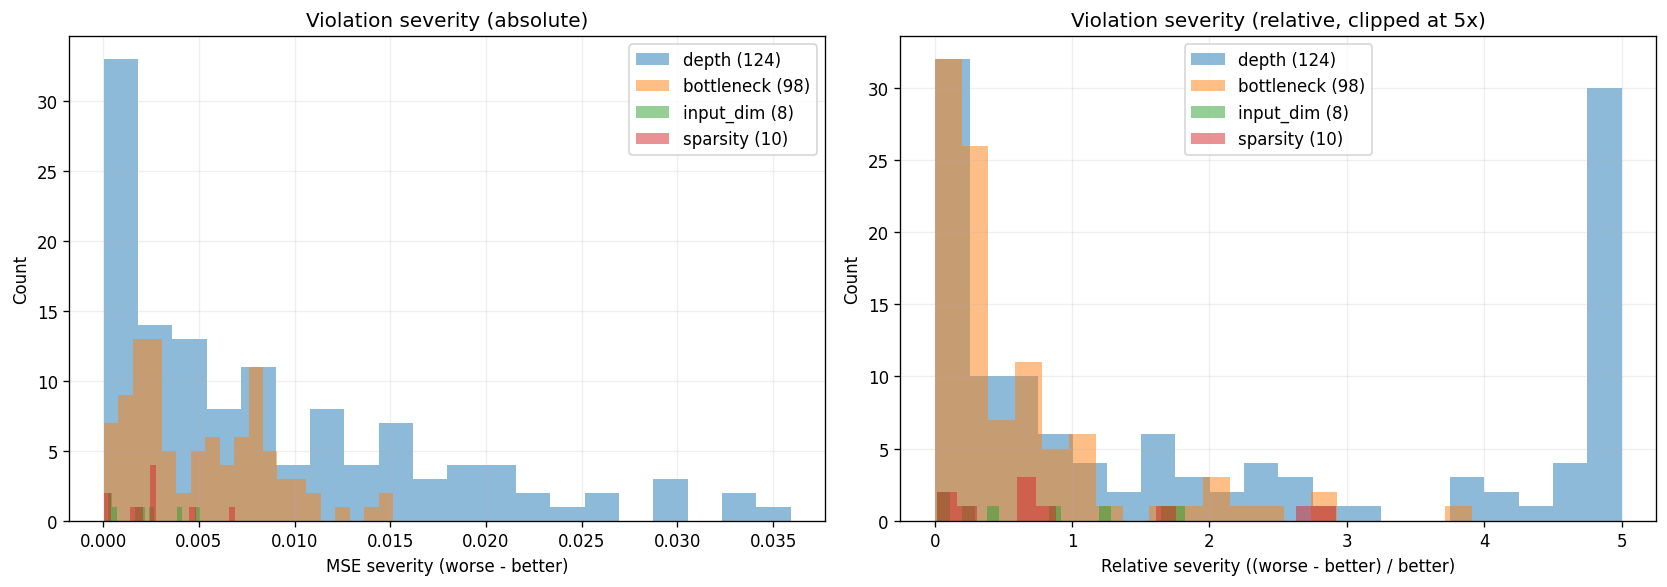

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute severity
ax = axes[0]
for vtype, color in [('depth', 'C0'), ('bottleneck', 'C1'), ('input_dim', 'C2'), ('sparsity', 'C3')]:
    sub = vdf[vdf.type == vtype]
    if len(sub) > 0:
        ax.hist(sub['severity'], bins=20, alpha=0.5, label=f'{vtype} ({len(sub)})', color=color)
ax.set_xlabel('MSE severity (worse - better)')
ax.set_ylabel('Count')
ax.set_title('Violation severity (absolute)')
ax.legend()
ax.grid(alpha=0.2)

# Relative severity
ax = axes[1]
for vtype, color in [('depth', 'C0'), ('bottleneck', 'C1'), ('input_dim', 'C2'), ('sparsity', 'C3')]:
    sub = vdf[vdf.type == vtype]
    if len(sub) > 0:
        ax.hist(sub['rel_severity'].clip(upper=5), bins=20, alpha=0.5, 
               label=f'{vtype} ({len(sub)})', color=color)
ax.set_xlabel('Relative severity ((worse - better) / better)')
ax.set_ylabel('Count')
ax.set_title('Violation severity (relative, clipped at 5x)')
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Which Configs Need Retraining?

A config that appears on the "worse" side of a violation is an optimization failure.
Rank configs by how many violations they appear in and the total severity.

In [7]:
# For each config, count how many times it's the "worse" side of a violation
# The "worse" config is the one that SHOULD have been better but isn't

failure_counts = {}

for _, v in vdf.iterrows():
    # Identify the config that failed
    if v['type'] == 'depth':
        # The deeper config failed
        key = (v['n'], v['m'], v['param_worse'], v['S'])
    elif v['type'] == 'bottleneck':
        # The wider config failed
        key = (v['n'], v['param_worse'], v['l'], v['S'])
    elif v['type'] == 'input_dim':
        # The smaller-n config failed
        key = (v['param_worse'], v['m'], v['l'], v['S'])
    elif v['type'] == 'sparsity':
        # The sparser config failed
        key = (v['n'], v['m'], v['l'], v['param_worse'])
    
    if key not in failure_counts:
        failure_counts[key] = {'n_violations': 0, 'total_severity': 0, 
                               'max_severity': 0, 'types': set()}
    failure_counts[key]['n_violations'] += 1
    failure_counts[key]['total_severity'] += v['severity']
    failure_counts[key]['max_severity'] = max(failure_counts[key]['max_severity'], v['severity'])
    failure_counts[key]['types'].add(v['type'])

failures = []
for (n, m, l, S), info in failure_counts.items():
    row = df[(df.n == n) & (df.m == m) & (df.l == l) & (df.S == S)]
    if len(row) == 0:
        continue
    r = row.iloc[0]
    failures.append({
        'n': int(n), 'm': int(m), 'l': int(l), 'S': S,
        'mse_full': r['mse_full'],
        'nonlinear_gain': r['nonlinear_gain'],
        'n_seeds': int(r['n_seeds']),
        'n_violations': info['n_violations'],
        'total_severity': round(info['total_severity'], 5),
        'max_severity': round(info['max_severity'], 5),
        'violation_types': ', '.join(sorted(info['types'])),
    })

df_fail = pd.DataFrame(failures).sort_values('total_severity', ascending=False)

print(f'Configs with at least one violation: {len(df_fail)} / {len(df)}')
print(f'Configs with multiple violation types: {(df_fail.violation_types.str.contains(",")).sum()}')
print()
print('Top 30 worst optimization failures:')
print(df_fail.head(30).to_string(index=False))

Configs with at least one violation: 65 / 216
Configs with multiple violation types: 35

Top 30 worst optimization failures:
  n  m  l    S  mse_full  nonlinear_gain  n_seeds  n_violations  total_severity  max_severity                        violation_types
 64 32  4 0.85  0.033165        0.002952       18             7         0.10205       0.02977                      bottleneck, depth
128 64  4 0.85  0.039656        0.004362       17             6         0.09503       0.03591                      bottleneck, depth
128 64  3 0.85  0.036954        0.001800       17             6         0.09031       0.03321                      bottleneck, depth
128 32  4 0.85  0.040825        0.009579       12             7         0.07833       0.02682                      bottleneck, depth
 32 16  4 0.85  0.021627        0.037431       12             5         0.07350       0.01850                      bottleneck, depth
128 64  4 0.90  0.026932        0.002332       17             8         0.070

In [8]:
# Summary: what fraction of configs are clean?
all_configs = set(zip(df.n, df.m, df.l, df.S))
failed_configs = set(zip(df_fail.n, df_fail.m, df_fail.l, df_fail.S))
clean_configs = all_configs - failed_configs

print(f'Clean configs (no violations): {len(clean_configs)} / {len(all_configs)} ({100*len(clean_configs)/len(all_configs):.0f}%)')
print(f'Failed configs: {len(failed_configs)} / {len(all_configs)} ({100*len(failed_configs)/len(all_configs):.0f}%)')
print()

# By depth
for l in l_vals:
    total = len([c for c in all_configs if c[2] == l])
    failed = len([c for c in failed_configs if c[2] == l])
    print(f'l={l}: {failed}/{total} failed ({100*failed/total:.0f}%)')

print()
# If we trust only clean configs, what does the phase diagram look like?
df_clean = df[df.apply(lambda r: (r['n'], r['m'], r['l'], r['S']) in clean_configs, axis=1)]
nl_clean = df_clean[df_clean.l >= 2]
print(f'Clean nonlinear configs: {len(nl_clean)}')
print(f'  Mean gain: {nl_clean.nonlinear_gain.mean():.3f}')
print(f'  Gain < 0.02: {(nl_clean.nonlinear_gain < 0.02).sum()}')

Clean configs (no violations): 151 / 216 (70%)
Failed configs: 65 / 216 (30%)

l=1: 0/54 failed (0%)
l=2: 9/54 failed (17%)
l=3: 19/54 failed (35%)
l=4: 37/54 failed (69%)

Clean nonlinear configs: 97
  Mean gain: 0.677
  Gain < 0.02: 0


## Per-Seed Analysis of Worst Violations
For the worst failures, look at the per-seed distribution to understand the optimization landscape.

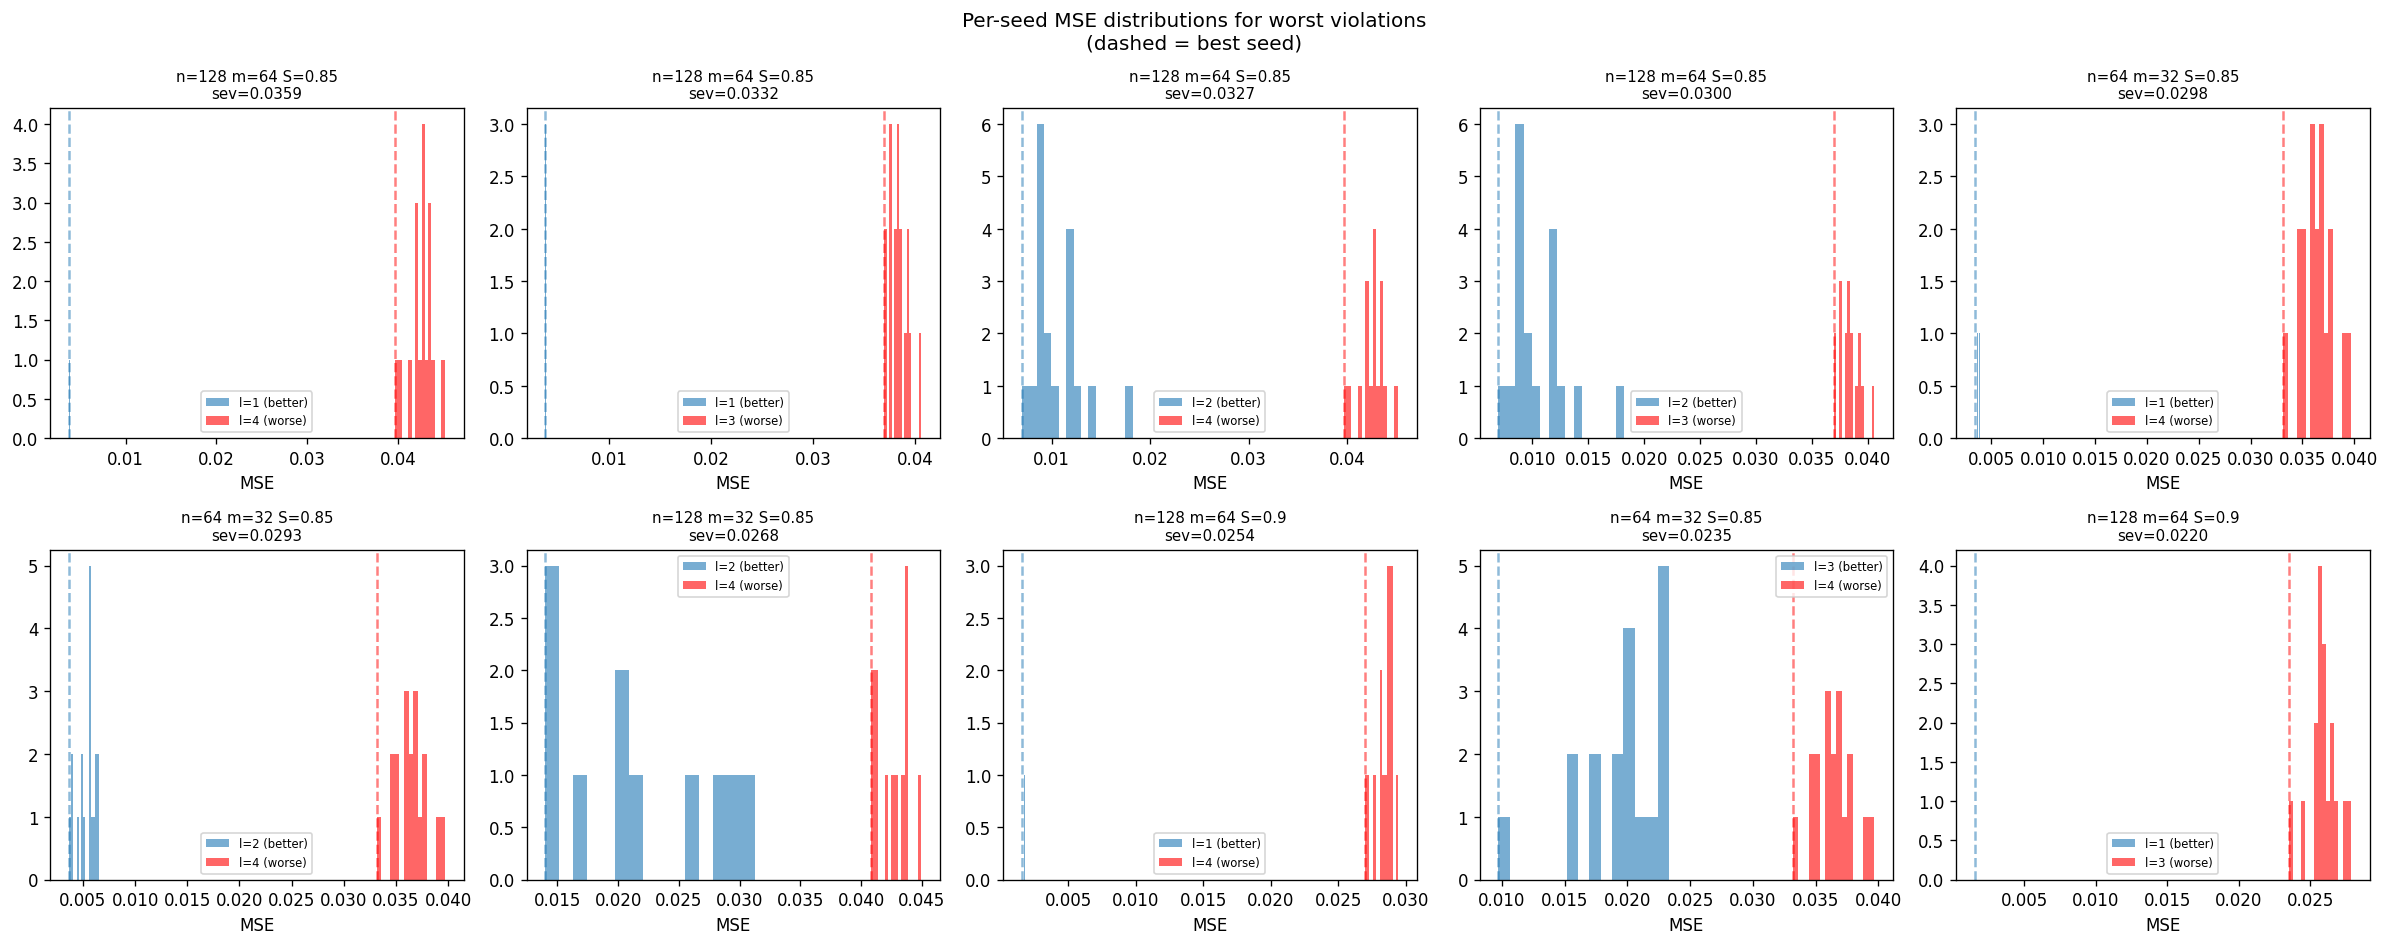

In [9]:
# For top 10 worst violations, compare per-seed MSE distributions
worst = vdf.sort_values('severity', ascending=False).head(10)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for idx, (_, v) in enumerate(worst.iterrows()):
    ax = axes[idx // 5, idx % 5]
    
    if v['type'] == 'depth':
        n, m, S = int(v['n']), int(v['m']), v['S']
        l_good, l_bad = int(v['param_better']), int(v['param_worse'])
        seeds_good = load_seeds(n, m, l_good, S)
        seeds_bad = load_seeds(n, m, l_bad, S)
        label_good = f'l={l_good}'
        label_bad = f'l={l_bad}'
        title = f'n={n} m={m} S={S}'
    elif v['type'] == 'bottleneck':
        n, l_val, S = int(v['n']), int(v['l']), v['S']
        m_good, m_bad = int(v['param_better']), int(v['param_worse'])
        seeds_good = load_seeds(n, m_good, l_val, S)
        seeds_bad = load_seeds(n, m_bad, l_val, S)
        label_good = f'm={m_good}'
        label_bad = f'm={m_bad}'
        title = f'n={n} l={l_val} S={S}'
    else:
        continue
    
    mse_good = [s['mse_full'] for s in seeds_good]
    mse_bad = [s['mse_full'] for s in seeds_bad]
    
    if mse_good and mse_bad:
        ax.hist(mse_good, bins=15, alpha=0.6, label=f'{label_good} (better)', color='C0')
        ax.hist(mse_bad, bins=15, alpha=0.6, label=f'{label_bad} (worse)', color='red')
        ax.axvline(min(mse_good), color='C0', ls='--', alpha=0.5)
        ax.axvline(min(mse_bad), color='red', ls='--', alpha=0.5)
    
    ax.set_title(f'{title}\nsev={v["severity"]:.4f}', fontsize=9)
    ax.set_xlabel('MSE')
    ax.legend(fontsize=7)

fig.suptitle('Per-seed MSE distributions for worst violations\n(dashed = best seed)', fontsize=12)
plt.tight_layout()
plt.show()